In [ ]:
print("Hello World")

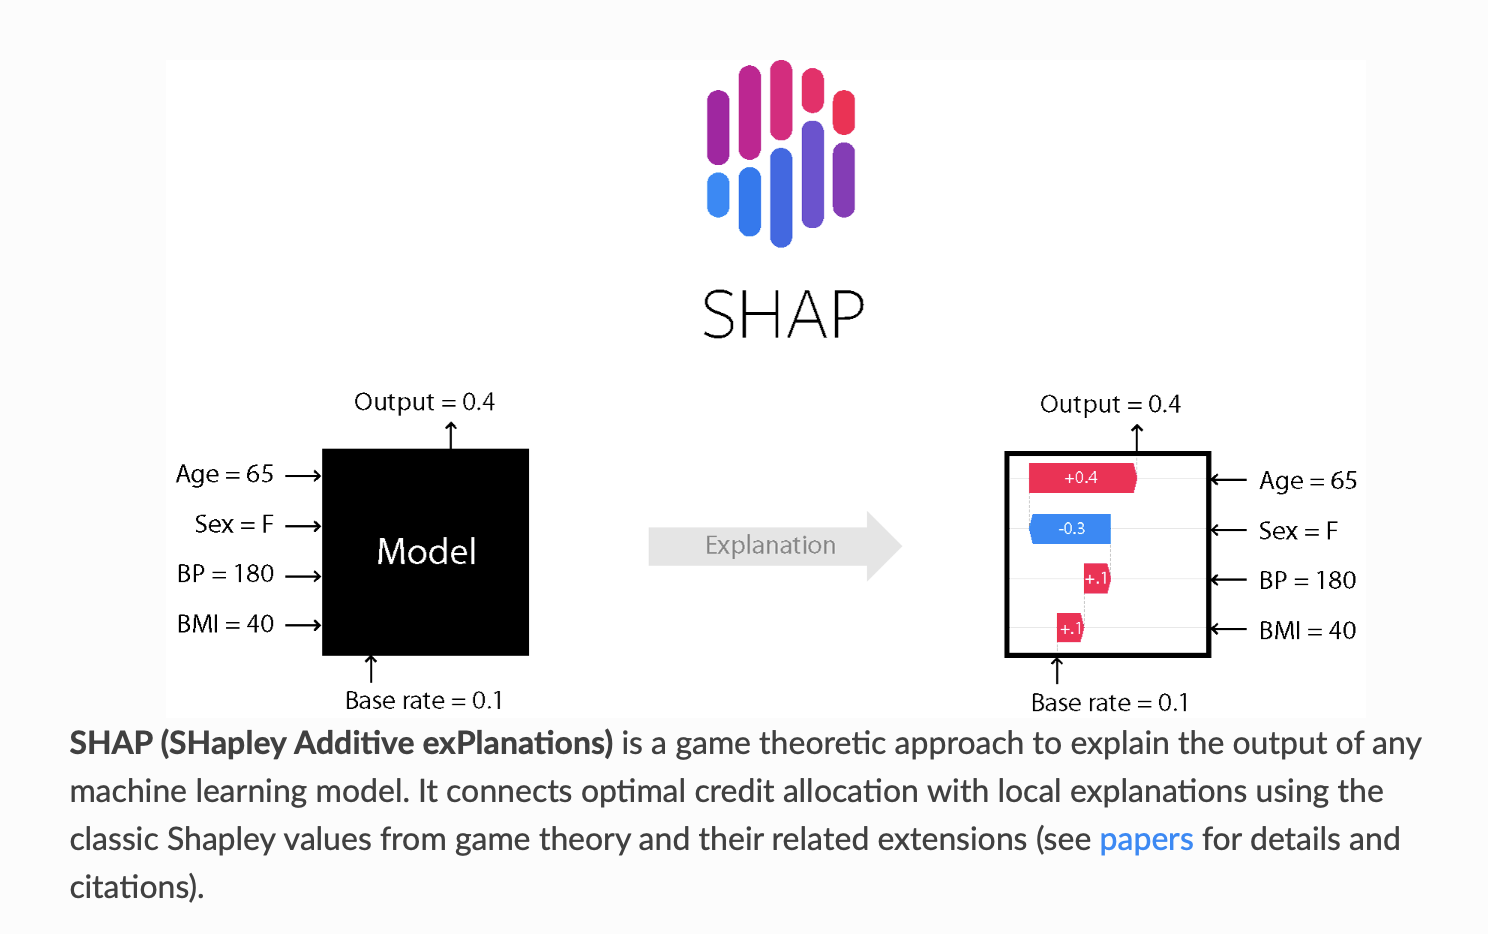

In [1]:
import requests
import pandas as pd

api_key = "402f219e7f6727dc638aa2ef651ee504"
cities = ["Chennai", "Mumbai", "Delhi", "Bangalore"]

all_data = []

for city in cities:
    url = f"https://api.openweathermap.org/data/2.5/weather?q={city}&appid={api_key}&units=metric"
    
    response = requests.get(url)
    data = response.json()

    # 🔥 CHECK BEFORE ACCESSING
    if response.status_code == 200 and 'main' in data:
        weather_data = {
            "city": city,
            "temperature": data['main']['temp'],
            "humidity": data['main']['humidity'],
            "weather": data['weather'][0]['description']
        }
        all_data.append(weather_data)
    else:
        print(f"Error for {city}: {data}")

df = pd.DataFrame(all_data)
df.to_csv("weather_data.csv", index=False)

print("Done")

Done


In [2]:
import requests
import pandas as pd
import time

api_key = "402f219e7f6727dc638aa2ef651ee504"
cities = ["Chennai", "Mumbai", "Delhi", "Bangalore"]

all_data = []

for i in range(20):  # collect multiple samples
    for city in cities:
        url = f"https://api.openweathermap.org/data/2.5/weather?q={city}&appid={api_key}&units=metric"
        response = requests.get(url)
        data = response.json()

        if response.status_code == 200 and 'main' in data:
            row = {
                "city": city,
                "temp": data['main']['temp'],
                "humidity": data['main']['humidity'],
                "pressure": data['main']['pressure'],
                "wind_speed": data['wind']['speed']
            }
            all_data.append(row)

    time.sleep(2)  # avoid rate limit

df = pd.DataFrame(all_data)
df.to_csv("weather_dataset.csv", index=False)

In [8]:
df.head(10)

,city,temp,humidity,pressure,wind_speed
0,Chennai,28.69,71,1014,1.54
1,Mumbai,28.99,54,1014,2.57
2,Delhi,24.05,57,1014,1.03
3,Bangalore,26.04,54,1015,3.60
4,Chennai,28.69,71,1014,1.54
5,Mumbai,28.99,54,1014,2.57
6,Delhi,24.05,57,1014,1.03
7,Bangalore,26.04,54,1015,3.60
8,Chennai,28.69,71,1014,1.54
9,Mumbai,28.99,54,1014,2.57


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

X = df[['humidity', 'pressure', 'wind_speed']]
y = df['temp']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = RandomForestRegressor()
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


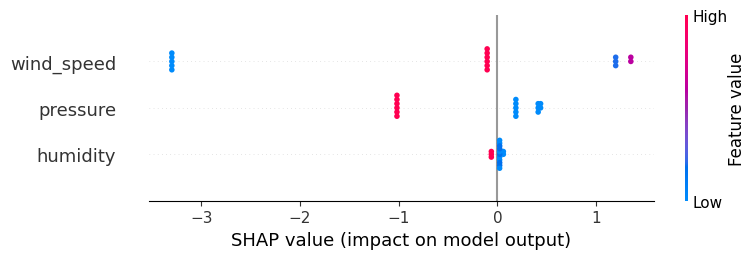

In [5]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)

In [12]:
import requests
import pandas as pd
import time
from datetime import datetime
import os

api_key = "402f219e7f6727dc638aa2ef651ee504" 

cities = ["Chennai", "Mumbai", "Delhi", "Bangalore"]

all_data = []

for i in range(200):  
    for city in cities:
        url = f"https://api.openweathermap.org/data/2.5/weather?q={city}&appid={api_key}&units=metric"
        
        response = requests.get(url)
        data = response.json()

        if response.status_code == 200 and 'main' in data:
            weather_main = data['weather'][0]['main']

            row = {
                "datetime": datetime.now(),  
                "city": city,
                "temp": data['main']['temp'],
                "humidity": data['main']['humidity'],
                "pressure": data['main']['pressure'],
                "wind_speed": data['wind']['speed'],
                "clouds": data['clouds']['all'],  
                "weather": weather_main,
                "rain": 1 if weather_main.lower() == "rain" else 0  # 🎯 TARGET
            }

            all_data.append(row)

        else:
            print(f"Error for {city}: {data}")

    time.sleep(2)

df = pd.DataFrame(all_data)

file_name = "weather_dataset.csv"

# 🔥 APPEND instead of overwrite
if os.path.exists(file_name):
    df.to_csv(file_name, mode='a', header=False, index=False)
else:
    df.to_csv(file_name, index=False)

print("Data saved")

KeyboardInterrupt: 

#---Titanic Dataset---#


In [20]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

In [13]:
df = pd.read_csv("Titanic-cleaned.csv")

In [14]:
df.head(10)

,Unnamed: 0,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Has_Cabin
0,0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,0
1,1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,1
2,2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,0
3,3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,1
4,4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,0
5,5,6,0,3,"Moran, Mr. James",male,24.0,0,0,330877,8.4583,Q,0
6,6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,S,1
7,7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,S,0
8,8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,S,0
9,9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,C,0


In [15]:
df = df.drop(['Unnamed: 0', 'PassengerId', 'Name', 'Ticket'], axis=1)

In [16]:
#one-hot encoding
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)

In [17]:
df.head(10)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Has_Cabin,Embarked_Q,Embarked_S
0,0,3,0,22.0,1,0,7.2500,0,False,True
1,1,1,1,38.0,1,0,71.2833,1,False,False
2,1,3,1,26.0,0,0,7.9250,0,False,True
3,1,1,1,35.0,1,0,53.1000,1,False,True
4,0,3,0,35.0,0,0,8.0500,0,False,True
5,0,3,0,24.0,0,0,8.4583,0,True,False
6,0,1,0,54.0,0,0,51.8625,1,False,True
7,0,3,0,2.0,3,1,21.0750,0,False,True
8,1,3,1,27.0,0,2,11.1333,0,False,True
9,1,2,1,14.0,1,0,30.0708,0,False,False


In [18]:
#feature engineering

df['family_size'] = df['SibSp'] + df['Parch']
df['is_alone'] = (df['family_size'] == 0).astype(int)
df['fare_per_person'] = df['Fare'] / (df['family_size'] + 1)

In [19]:
df.head(10)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Has_Cabin,Embarked_Q,Embarked_S,family_size,is_alone,fare_per_person
0,0,3,0,22.0,1,0,7.2500,0,False,True,1,0,3.62500
1,1,1,1,38.0,1,0,71.2833,1,False,False,1,0,35.64165
2,1,3,1,26.0,0,0,7.9250,0,False,True,0,1,7.92500
3,1,1,1,35.0,1,0,53.1000,1,False,True,1,0,26.55000
4,0,3,0,35.0,0,0,8.0500,0,False,True,0,1,8.05000
5,0,3,0,24.0,0,0,8.4583,0,True,False,0,1,8.45830
6,0,1,0,54.0,0,0,51.8625,1,False,True,0,1,51.86250
7,0,3,0,2.0,3,1,21.0750,0,False,True,4,0,4.21500
8,1,3,1,27.0,0,2,11.1333,0,False,True,2,0,3.71110
9,1,2,1,14.0,1,0,30.0708,0,False,False,1,0,15.03540


In [21]:
#using randomforest for train data

X = df.drop('Survived', axis=1)
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = RandomForestClassifier(n_estimators=100)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

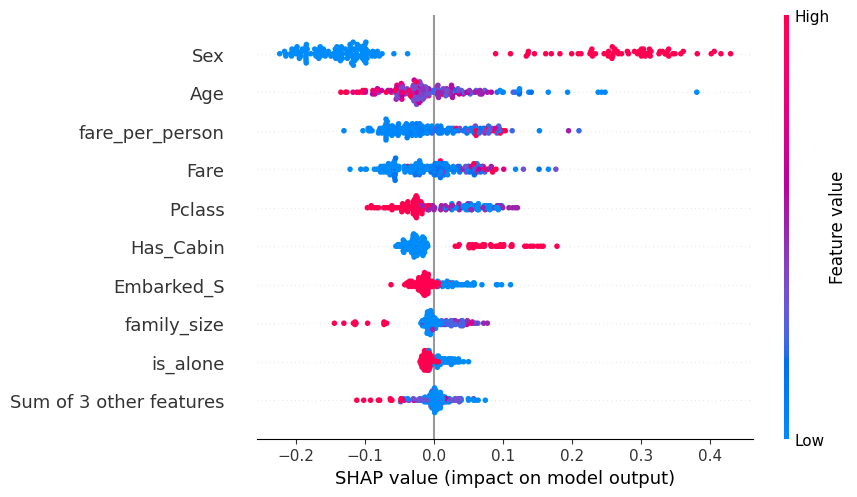

In [25]:
# SHAP

import shap

explainer = shap.TreeExplainer(model)

shap_values = explainer(X_test)

# select class 1 (survived)
shap.plots.beeswarm(shap_values[:,:,1])